# Z-SCORE

<h3 style='color:plum'># Only applicable to Normal data distbtn</h3>

<img src='Screenshot 2026-02-26 195810.png'><img>

- A/c to Z-score, 68% of data should be present in range of u + ~
- 95% should be in u + 2~ range
- Outside the range of -3~ to 3~, We can consider Anything outside it to be Outliers
- Here u(mean) and ~(std)
- Z-score(Xi') = (Xi - u) / ~

> Technique to remove Outliers:
- Trimming means removing outliers by considering vals outer 3~ as outliers
- Capping means replacing Outliers with max/min vals

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\100DaysOfMl\HandlingOutliers\placement_ex.csv')

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


C:\Users\HP\AppData\Local\Temp\ipykernel_2392\4261954603.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\HP\AppData\Local\Temp\ipykernel_2392\4261954603.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


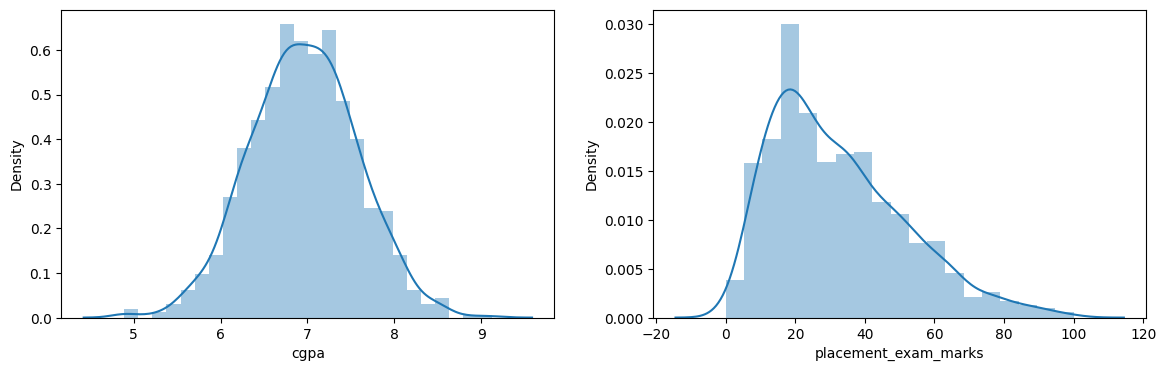

In [11]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(df['cgpa'])
plt.subplot(122)
sns.distplot(df['placement_exam_marks'])
plt.show()

- So by analysing graph we can only apply z-score on cgpa(Normal) not on placement col(skewed)

In [ ]:
# getting statistical data of cgpa col
print("Mean of cgpa", df['cgpa'].mean())
print("Std of cgpa", df['cgpa'].std())
print("Min of cgpa", df['cgpa'].min())
print("Max of cgpa", df['cgpa'].max())

Mean of cgpa 6.96124
Std of cgpa 0.6158978751323896
Min of cgpa 4.89
Max of cgpa 9.12


In [13]:
# finding boundary val
print('Highest allowed in cgpa', df['cgpa'].mean() + 3*df['cgpa'].std())
print('Lowest allowed in cgpa', df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed in cgpa 8.808933625397168
Lowest allowed in cgpa 5.113546374602832


In [4]:
# finding Outliers
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


> <h3>a. Trimming</h3>

In [5]:
new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


> <h3>b. Z-score</h3>

In [6]:
# calculating z-score
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean()) / (df['cgpa'].std())

In [7]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


- Now we need to check our data is in range of 3 zscore or not

In [23]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_new,cgpa_zscore
485,4.92,44.0,1,-3.314251,-3.314251
997,4.89,34.0,0,-3.362960,-3.362960
999,4.90,10.0,1,-3.346724,-3.346724


In [24]:
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_new,cgpa_zscore
995,8.87,44.0,1,3.099150,3.099150
996,9.12,65.0,1,3.505062,3.505062


In [25]:
# Trimming
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [26]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_new,cgpa_zscore
0,7.19,26.0,1,0.371425,0.371425
1,7.46,38.0,1,0.809810,0.809810
2,7.54,40.0,1,0.939701,0.939701
3,6.42,8.0,1,-0.878782,-0.878782
4,7.23,17.0,0,0.436371,0.436371
...,...,...,...,...,...
991,7.04,57.0,0,0.127878,0.127878
992,6.26,12.0,0,-1.138565,-1.138565
993,6.73,21.0,1,-0.375452,-0.375452
994,6.48,63.0,0,-0.781363,-0.781363


- Capping

In [8]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()
upper_limit

np.float64(8.808933625397168)

- 3 arg in np.where(x,y,z)
- np.where(condn, what if true(replacement), what if false)

In [9]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        df['cgpa'] < lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [11]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

# IQR

<img src='Screenshot 2026-02-27 181809.png'></img>

<h3 style='color:plum'># Only applicable to Skewed data</h3>

- IQR = 75%ile - 25%ile
- 100%ile means Max val or all vals are less than that
- IQR Proximity rule : (Q3 +/- 1.5*IQR)

In [15]:
ndf = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\100DaysOfMl\HandlingOutliers\placement_ex.csv')

In [16]:
ndf.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [17]:
ndf['cgpa'].skew()
ndf['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

Here placement col is right skewed

In [18]:
ndf['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

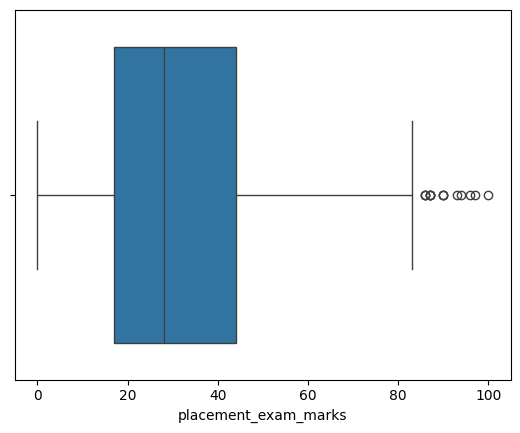

In [20]:
sns.boxplot(x=ndf['placement_exam_marks'])

In [21]:
# finding percentile vals
percentile25 = ndf['placement_exam_marks'].quantile(0.25)
percentile75 = ndf['placement_exam_marks'].quantile(0.75)

In [22]:
percentile25

np.float64(17.0)

In [24]:
# finding IQR
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

In [26]:
upper_limit = percentile75 + (1.5 * iqr)
lower_limit = percentile25 - 1.5 * iqr
print(upper_limit)
print(lower_limit)

84.5
-23.5


> Finding Outliers

In [27]:
ndf[ndf['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [28]:
ndf[ndf['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


<h4 style='color:plum'># Trimming</h4>

In [29]:
new_df = ndf[ndf['placement_exam_marks'] < upper_limit]

In [31]:
new_df.shape

(985, 3)

C:\Users\HP\AppData\Local\Temp\ipykernel_8400\3329918580.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ndf['placement_exam_marks'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8400\3329918580.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam_marks'])


<Axes: xlabel='placement_exam_marks'>

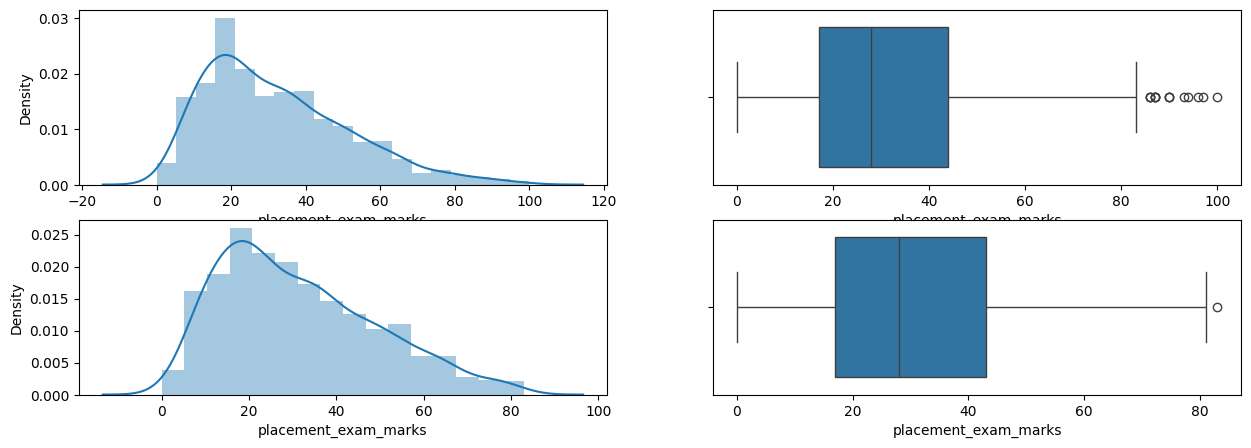

In [ ]:
# plotting the change
plt.figure(figsize=(15,5))
plt.subplot(221)
sns.distplot(ndf['placement_exam_marks'])

plt.subplot(222)
sns.boxplot(x=ndf['placement_exam_marks'])

plt.subplot(223)
sns.distplot(new_df['placement_exam_marks'])

plt.subplot(224)
sns.boxplot(x=new_df['placement_exam_marks'])

<h3 style='color:plum'># Capping</h3>

In [33]:
new_df_cap = ndf.copy()

In [34]:
new_df_cap = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [46]:
new_df_cap = pd.DataFrame(new_df_cap)
new_df_cap.head()

,0
0,26.0
1,38.0
2,40.0
3,8.0
4,17.0


C:\Users\HP\AppData\Local\Temp\ipykernel_8400\2021677995.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ndf['placement_exam_marks'])
C:\Users\HP\AppData\Local\Temp\ipykernel_8400\2021677995.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap)


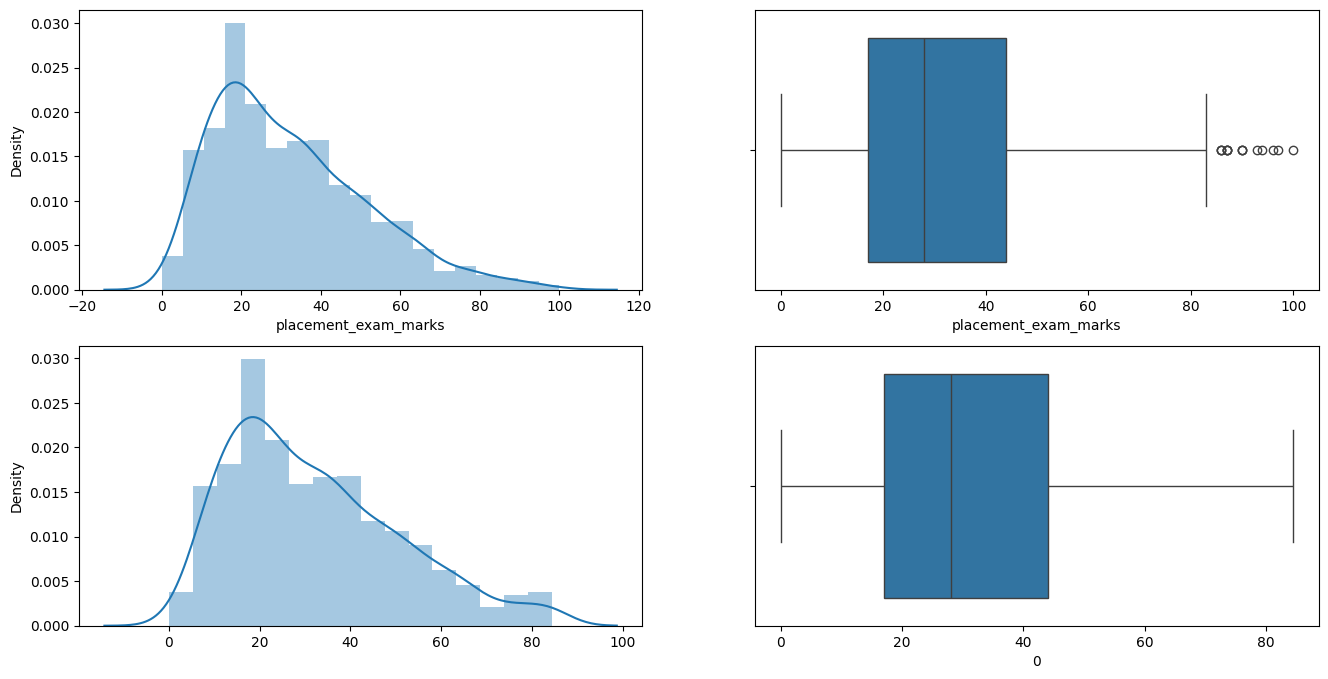

In [50]:
# plotting the change
plt.figure(figsize=(16,8))
plt.subplot(221)
sns.distplot(ndf['placement_exam_marks'])

plt.subplot(222)
sns.boxplot(x=ndf['placement_exam_marks'])

plt.subplot(223)
sns.distplot(new_df_cap)

plt.subplot(224)
sns.boxplot(x=new_df_cap[0])

plt.show()

<h2 style='color:plum'># Winsorization</h2>
- When Capping is done using Percentile method

In [68]:
wt = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\100DaysOfMl\HandlingOutliers\weight-height.csv')

In [69]:
wt.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [70]:
wt['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

C:\Users\HP\AppData\Local\Temp\ipykernel_8400\3077464284.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(wt['Height'])


<Axes: xlabel='Height', ylabel='Density'>

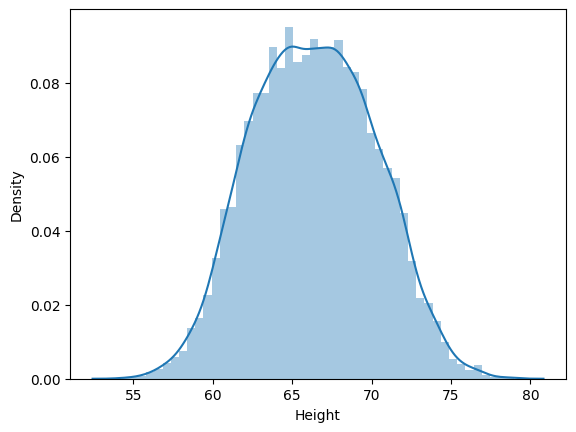

In [54]:
sns.distplot(wt['Height'])

<Axes: xlabel='Height'>

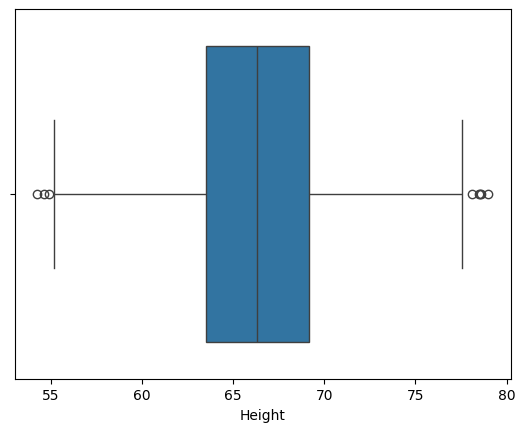

In [56]:
sns.boxplot(x=wt['Height'])

> #Trimming

In [71]:
upper_limit = wt['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [72]:
lower_limit = wt['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [73]:
wt_new = wt[(wt['Height'] <= 74.78) & (wt['Height'] >= 58.13)]

In [74]:
wt_new.shape

(9799, 3)

C:\Users\HP\AppData\Local\Temp\ipykernel_8400\3434341082.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(wt_new['Height'])


<Axes: xlabel='Height', ylabel='Density'>

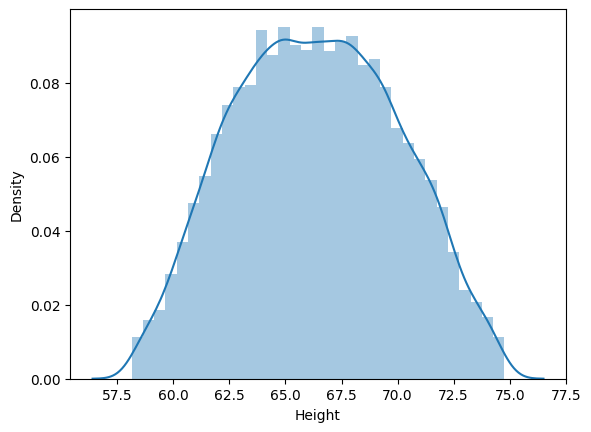

In [62]:
sns.distplot(wt_new['Height'])

<Axes: xlabel='Height'>

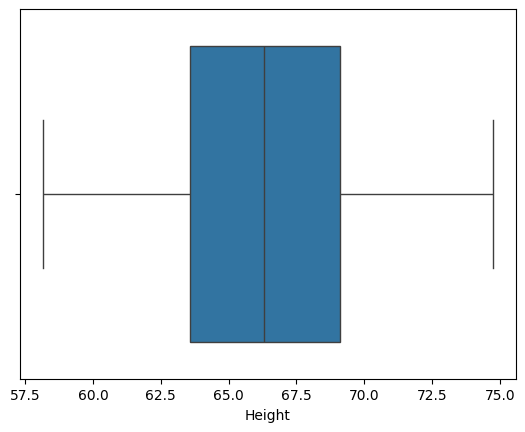

In [63]:
sns.boxplot(x=wt_new['Height'])

<h3 style='color:plum'># Winsorizatn / Capping</h3>

In [77]:
wt_new_cap = np.where(
    wt['Height'] > upper_limit,
    upper_limit,
    np.where(
        wt['Height'] < lower_limit,
        lower_limit,
        wt['Height']
    )
)

In [80]:
wt_new_cap = pd.DataFrame(wt_new_cap)

In [81]:
wt_new_cap.shape

(10000, 1)

In [83]:
wt_new_cap.describe()

,0
count,10000.000000
mean,66.366281
std,3.795717
min,58.134412
25%,63.505620
50%,66.318070
75%,69.174262
max,74.785790


C:\Users\HP\AppData\Local\Temp\ipykernel_8400\3167647208.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(wt_new_cap)


<Axes: ylabel='Density'>

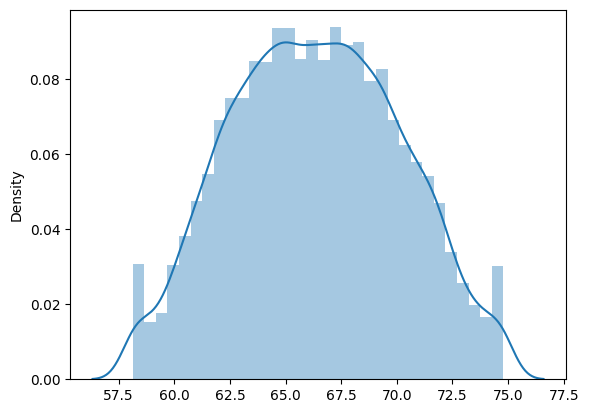

In [84]:
sns.distplot(wt_new_cap)

# A other library named Scipy is used for Winsorizatn